# AI Course Homework: Machine Learning Fundamentals

This notebook provides hands-on experience with key machine learning concepts: **Naive Bayes**, **Decision Trees**, **Regression (Polynomial and Logistic)**, **Neural Networks** and **CNN**. You'll implement algorithms from scratch and apply them to datasets to deepen your understanding. The notebook is divided into five sections, each with a theoretical overview and practical exercises.

**Instructions:**
- Complete all sections in the code and answer the questions.
- Submit the notebook with all code cells executed and outputs visible.
- Use `numpy` for basic operations, but implement core algorithm logic yourself where indicated



## Sections
1. **Naive Bayes**
2. **Decision Trees**
3. **Regression (Polynomial and Logistic)**
4. **Neural Networks (Perceptron and Multi-Layer Perceptron)**
5. **CNN From Scratch!**

In [59]:
Name="Zeynab Ashouri"
Student_Number="401103882"

## Section 1: Naive Bayes

### Theoretical Overview
**Naive Bayes** is a probabilistic classifier that assumes features are conditionally independent given the class label, using Bayes' theorem:

$$ P(Y | F_1, ..., F_n) \propto P(Y) \prod_{i} P(F_i | Y) $$

Here, you'll implement Naive Bayes for spam classification.

### Practical Exercise: Implementing Naive Bayes
**Dataset:** Emails labeled 'spam' or 'ham' with binary features 'free' and 'money'.

| free | money | label |
|------|-------|-------|
| 1    | 0     | spam  |
| 0    | 1     | spam  |
| 0    | 0     | ham   |
| 1    | 1     | spam  |
| 0    | 0     | ham   |

**Tasks:**
1. Calculate prior probabilities $ P(\text{spam}) $ and $ P(\text{ham}) $.
2. Calculate conditional probabilities with Laplace smoothing ($ k=1 $): $ P(\text{free}=1 | \text{spam}) $, $ P(\text{free}=1 | \text{ham}) $, $ P(\text{money}=1 | \text{spam}) $, $ P(\text{money}=1 | \text{ham}) $.
3. Predict the label for a new email: $ \text{free}=1 $, $ \text{money}=0 $.

**Questions:**
- Why is Laplace smoothing important?
  - **Answer:** prevents zero probabilities for unseen features, ensuring the model works with new data by adding small default probabilities.
- How does feature independence affect performance?
  - **Answer:** Naive Bayes assumes features are independent, which can hurt accuracy if they're actually correlated, but often still performs well in practice.

In [60]:
import numpy as np

# Toy dataset
data = np.array([
    [1, 0, 'spam'],
    [0, 1, 'spam'],
    [0, 0, 'ham'],
    [1, 1, 'spam'],
    [0, 0, 'ham']
])
X = data[:, :-1].astype(int)
y = data[:, -1]

# Calculate prior probabilities
#Without smoothing
total = len(y)
p_spam = np.sum(y == 'spam') / total
p_ham = np.sum(y == 'ham') / total
print(f'P(spam) = {p_spam}, P(ham) = {p_ham}')
#if smooth 
#total = len(y)
#p_spam = (np.sum(y == 'spam') + 1) / (total + 2)
#p_ham = (np.sum(y == 'ham') + 1) / (total + 2)

# Calculate conditional probabilities with Laplace smoothing
def conditional_prob(feature_idx, value, label, X, y, k=1):
    condition = (y == label)
    feature_count = np.sum(X[condition, feature_idx] == value)
    total_count = np.sum(condition)
    possible_values = 2
    return (feature_count + k) / (total_count + k * possible_values)

p_free1_spam = conditional_prob(0, 1, 'spam', X, y)
p_free1_ham = conditional_prob(0, 1, 'ham', X, y)
p_money1_spam = conditional_prob(1, 1, 'spam', X, y)
p_money1_ham = conditional_prob(1, 1, 'ham', X, y)
print(f'P(free=1|spam) = {p_free1_spam}, P(free=1|ham) = {p_free1_ham}')
print(f'P(money=1|spam) = {p_money1_spam}, P(money=1|ham) = {p_money1_ham}')

# Predict for new email
new_email = np.array([1, 0])
p_spam_email = p_spam * \
               (p_free1_spam if new_email[0] == 1 else (1 - p_free1_spam)) * \
               (p_money1_spam if new_email[1] == 1 else (1 - p_money1_spam))

p_ham_email = p_ham * \
              (p_free1_ham if new_email[0] == 1 else (1 - p_free1_ham)) * \
              (p_money1_ham if new_email[1] == 1 else (1 - p_money1_ham))
# Normalize
total_p = p_spam_email + p_ham_email
p_spam_norm = p_spam_email / total_p
p_ham_norm = p_ham_email / total_p

prediction = 'spam' if p_spam_norm > p_ham_norm else 'ham'
print(f'P(spam|free=1, money=0) = {p_spam_norm}, P(ham|free=1, money=0) = {p_ham_norm}')
print(f'Prediction: {prediction}')

P(spam) = 0.6, P(ham) = 0.4
P(free=1|spam) = 0.6, P(free=1|ham) = 0.25
P(money=1|spam) = 0.6, P(money=1|ham) = 0.25
P(spam|free=1, money=0) = 0.6575342465753424, P(ham|free=1, money=0) = 0.34246575342465757
Prediction: spam


## Section 2: Decision Trees

### Theoretical Overview
**Decision Trees** split data based on features to maximize **information gain**:

$$ IG(X_i) = H(Y) - H(Y | X_i) $$
$$ H(Y) = -\sum_c P(Y=c) \log_2 P(Y=c) $$

where $ H $ is entropy. Overfitting is a risk, addressed by pruning.

### Practical Exercise: Implementing a Decision Tree
**Dataset:** Features $ \text{age} $ (young/old), $ \text{income} $ (low/high), $ \text{student} $ (yes/no), and label $ \text{buys\_product} $ (yes/no).

| age   | income | student | buys_product |
|-------|--------|---------|--------------|
| young | high   | no      | no           |
| young | high   | yes     | yes          |
| old   | high   | no      | yes          |
| old   | low    | yes     | yes          |
| young | low    | no      | no           |
| old   | low    | no      | no           |
| young | low    | yes     | yes          |
| old   | high   | yes     | yes          |

**Tasks:**
1. Implement entropy calculation.
2. Implement information gain calculation.
3. Build a tree with a max depth of 3, splitting on the highest information gain.
4. Apply pruning: stop splitting if gain < 0.1.
5. Predict for $ \text{age}=\text{young} $, $ \text{income}=\text{low} $, $ \text{student}=\text{no} $.

**Questions:**
- Why was a feature chosen for the root?
  - **Answer:** feature with the highest information gain (most entropy reduction) is picked for the root to make the strongest initial split, maximizing class separation early.  
- How does pruning prevent overfitting?
  - **Answer:** pruning removes weak splits, stopping the tree from growing too deep. This avoids over fitting and fitting noise, keeps the model simple.

In [61]:
import numpy as np

# Toy dataset
data = np.array([
    ['young', 'high', 'no', 'no'],
    ['young', 'high', 'yes', 'yes'],
    ['old', 'high', 'no', 'yes'],
    ['old', 'low', 'yes', 'yes'],
    ['young', 'low', 'no', 'no'],
    ['old', 'low', 'no', 'no'],
    ['young', 'low', 'yes', 'yes'],
    ['old', 'high', 'yes', 'yes']
])
X = data[:, :-1]
y = data[:, -1]

# Entropy calculation
def entropy(labels):
    label_counts = {}
    total = len(labels)
    for label in labels:
        label_counts[label] = label_counts.get(label, 0) + 1
    probs = [count / total for count in label_counts.values()]
    return -sum(p * np.log2(p) for p in probs)


H_y = entropy(y)
print(f'Entropy of buys_product: {H_y}')

# Information gain calculation
def info_gain(feature_idx, X, y):
    total_entropy = entropy(y)
    feature_values = X[:, feature_idx]
    value_distribution = {
        val: len(subset) / len(y) * entropy(subset)
        for val, subset in (
            (v, y[feature_values == v]) 
            for v in np.unique(feature_values)
        )
    }
    return total_entropy - sum(value_distribution.values())

# Decision Tree Node
class TreeNode:
    def __init__(self, feature=None, value=None, left=None, right=None, label=None):
        self.feature = feature
        self.value = value
        self.left = left
        self.right = right
        self.label = label

# Build Decision Tree
def build_tree(X, y, depth=0, max_depth=3, min_gain=0.1):
    def should_terminate():
        if len(np.unique(y)) == 1:
            return {'label': y[0]}
        if depth >= max_depth:
            return {'label': most_common_label(y)}
        return None
    
    if (terminal_node := should_terminate()) is not None:
        return terminal_node
    best_feature, best_gain = max(
        ((i, info_gain(i, X, y)) for i in range(X.shape[1])),
        key=lambda x: x[1]
    )
    if best_gain < min_gain:
        return {'label': most_common_label(y)}
    split_value = np.unique(X[:, best_feature])[0]
    left_mask = X[:, best_feature] == split_value
    return {
        'feature': best_feature,
        'value': split_value,
        'left': build_tree(X[left_mask], y[left_mask], depth+1, max_depth, min_gain),
        'right': build_tree(X[~left_mask], y[~left_mask], depth+1, max_depth, min_gain)
    }

def most_common_label(y):
    values, counts = np.unique(y, return_counts=True)
    return values[np.argmax(counts)]

# Predict

def predict(tree, x):
    while 'label' not in tree:
        tree = tree['left'] if x[tree['feature']] == tree['value'] else tree['right']
    return tree['label']


# Build and predict
tree = build_tree(X, y)
new_instance = ['young', 'low', 'no']
prediction = predict(tree, new_instance)
print(f'Prediction for young, low, no: {prediction}')

Entropy of buys_product: 0.954434002924965
Prediction for young, low, no: no


## Section 3: Regression (Polynomial and Logistic)

### Theoretical Overview
**Polynomial Regression** fits continuous outcomes:

$$ y(x, \mathbf{w}) = \sum_{j=0}^{M} w_j x^j $$
- **Error:** $ E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^{N} (y(x_n, \mathbf{w}) - t_n)^2 $
- **Regularization:** Adds $ \frac{\lambda}{2} ||\mathbf{w}||^2 $ to prevent overfitting.

**Logistic Regression** predicts class probabilities:

$$ P(Y=1 | X) = \frac{1}{1 + \exp(-(\mathbf{w}^T X + b))} $$
- **Loss:** Cross-entropy.

### Practical Exercise: Polynomial and Logistic Regression
**Tasks:**
1. Fit polynomial regression (degrees 1, 3, 9) to a synthetic dataset and plot.
2. Apply Ridge regularization to degree 9 ($ \lambda = 0.01 $) and plot.
3. Implement logistic regression with gradient descent on the Decision Tree dataset.
4. Compare polynomial and logistic regression on the classification task.

**Questions:**
- Why does degree 9 overfit?
  - **Answer:** a 9th-degree polynomial has too many coefficients, letting it chase noise in the training data instead of the real trend. It fits perfectly to training points (even random fluctuations) but fails on new data   
- How does regularization help?
  - **Answer:** regularization adds a penalty to shrink coefficients toward zero and reduce extreme model complexity and smooth out polynomial swings and accuracy and simplicity for better generalization  

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Polynomial Regression
np.random.seed(0)
X_poly = np.linspace(0, 1, 10).reshape(-1, 1)
y_poly = np.sin(2 * np.pi * X_poly).ravel() + np.random.normal(0, 0.1, 10)

def polynomial_features(X, degree):
    X_poly = np.ones((X.shape[0], 1))
    for d in range(1, degree + 1):
        X_poly = np.hstack((X_poly, X ** d))
    return X_poly

def fit_polynomial(X_poly, y, lambda_reg=0):
    if lambda_reg > 0:
        reg_matrix = lambda_reg * np.eye(X_poly.shape[1])
        reg_matrix[0, 0] = 0
        w = np.linalg.inv(X_poly.T @ X_poly + reg_matrix) @ X_poly.T @ y
    else:
        w = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y
    return w

def predict(X_poly, w):
    return X_poly @ w

def sse(y_true, y_pred):
    return np.sum((y_true - y_pred) ** 2)

# Polynomial fits
degrees = [1, 3, 9]
plt.figure(figsize=(12, 4))
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
for i, deg in enumerate(degrees, 1):
    X_poly_train = polynomial_features(X_poly, deg)
    w = fit_polynomial(X_poly_train, y_poly)
    y_pred = predict(X_poly_train, w)
    X_test_poly = polynomial_features(X_test, deg)
    y_test_pred = predict(X_test_poly, w)
    error = sse(y_poly, y_pred)
    plt.subplot(1, 4, i)
    plt.scatter(X_poly, y_poly, color='blue', label='Data')
    plt.plot(X_test, y_test_pred, 'r-', label=f'Degree {deg}')
    plt.title(f'Degree {deg}, SSE={error:.2f}')
    plt.legend()

# Regularized degree 9
X_poly_9 = polynomial_features(X_poly, 9)
w_reg = fit_polynomial(X_poly_9, y_poly, lambda_reg=0.01)
y_pred_reg = predict(X_poly_9, w_reg)
X_test_poly_9 = polynomial_features(X_test, 9)
y_test_pred_reg = predict(X_test_poly_9, w_reg)
error_reg = sse(y_poly, y_pred_reg)
plt.subplot(1, 4, 4)
plt.scatter(X_poly, y_poly, color='blue', label='Data')
plt.plot(X_test, y_test_pred_reg, 'g-', label='Deg 9 Reg')
plt.title(f'Degree 9 Reg, SSE={error_reg:.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('regression_plots.png')
#import os
#print(os.path.abspath('regression_plots.png'))
plt.close()

# Logistic Regression
X_log = np.array([
    [0, 0, 0],  # young, high, no
    [0, 0, 1],  # young, high, yes
    [1, 0, 0],  # old, high, no
    [1, 1, 1],  # old, low, yes
    [0, 1, 0],  # young, low, no
    [1, 1, 0],  # old, low, no
    [0, 1, 1],  # young, low, yes
    [1, 0, 1]   # old, high, yes
])
y_log = np.array([0, 1, 1, 1, 0, 0, 1, 1])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_regression(X, y, lr=0.1, epochs=1000):
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        z = X @ w
        gradient = X.T @ (sigmoid(z) - y)
        w -= lr * gradient
    return w

w_log = logistic_regression(X_log, y_log)
new_instance_log = np.array([0, 1, 0])
new_instance_log = np.hstack([1, new_instance_log])
prob = sigmoid(np.dot(new_instance_log, w_log))
prediction_log = 1 if prob > 0.5 else 0
print(f'Logistic Regression prediction for young, low, no: {prediction_log}')

Logistic Regression prediction for young, low, no: 0


## Section 4: Neural Networks (Perceptron and Multi-Layer Perceptron)

### Theoretical Overview
**Perceptron:** A linear classifier.
**Multi-Layer Perceptron (MLP):** Adds hidden layers for non-linear problems.

### Practical Exercise: Implementing Perceptron and MLP
**Dataset:**
| $x_1$ | $x_2$ | $y$ |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

**Tasks:**
1. Implement and train a perceptron.
2. Implement and train an MLP with 2 hidden units.
3. Compare their performance.

**Questions:**
- Why can't the perceptron solve XOR?
  - **Answer:** a perceptron can only draw straight lines. XOR needs curved separation, which a single perceptron can't do.
- How does the MLP help?
  - **Answer:** MLPs add hidden layers with non-linear functions. These layers bend and combine the input space, letting the final layer draw the needed separation line

In [63]:
import numpy as np

# Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# Perceptron
class Perceptron:
    def __init__(self):
        self.w = np.zeros(3)
    
    def predict(self, x):
        x_with_bias = np.array([x[0], x[1], 1])
        return 1 if np.dot(self.w, x_with_bias) >= 0 else 0
    
    def train(self, X, y, epochs=50):
        for _ in range(epochs):
            for i in range(len(X)):
                x = X[i]
                predict = self.predict(x)
                x_with_bias = np.array([x[0], x[1], 1])
                self.w += ( y[i] - predict) * x_with_bias

perceptron = Perceptron()
perceptron.train(X, y)
print('Perceptron predictions:', [perceptron.predict(x) for x in X])

# MLP
class MLP:
    def __init__(self, hidden_size=2, lr=0.5):
        self.lr = lr
        self.W1 = np.random.randn(2, hidden_size) * 0.1
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.randn(hidden_size, 1) * 0.1
        self.b2 = np.zeros(1)
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_deriv(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2
    
    def train(self, X, y, epochs=50000):
        y = y.reshape(-1, 1)
        for _ in range(epochs):
            delta2 = (self.forward(X) - y) * self.sigmoid_deriv(self.z2)
            delta1 = delta2.dot(self.W2.T) * self.sigmoid_deriv(self.z1)
            self.W2 -= self.lr * self.a1.T.dot(delta2)
            self.b2 -= self.lr * np.sum(delta2, axis=0)
            self.W1 -= self.lr * X.T.dot(delta1)
            self.b1 -= self.lr * np.sum(delta1, axis=0)
    
    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)

mlp = MLP()
mlp.train(X, y)
print('MLP predictions:', mlp.predict(X).flatten())

Perceptron predictions: [1, 1, 0, 0]
MLP predictions: [0 1 1 0]


## Section 5: CNN From Scratch!


__CNN__ s are powerfull tools to work with in the scope of _Computer Vision_. You have seen MLPs before and know how to do forward and backward pass on them. In this part, we want to create a convolutional layer (a simple one, of course!) just to understand well that how a Convolutional Layer works, behind the scenes. You can read more about Convolutional Neural Networks in this [Link](https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175)



__FORWARD PASS__:

In forward pass, you should apply the convolution operation on the input image. The convolution operation is as follows:

$$
\text{output}[i, j] = \sum_{k=0}^{K-1} \sum_{l=0}^{L-1} \text{input}[i+k, j+l] \times \text{kernel}[k, l]
$$

You can see a sample convolution operation (with a $3 \times 3$ kernel) in the following image:
<div style="text-align:center;">
  <img src="./Images/Conv.gif" /> 
</div>

Please note that, these are samples for you to understand the operation better. For _forward pass_ that you should implement, please notice that you should convolve the kernel along all $C$ channels of the input image. So, the output shape should be $(N, H_{out}, W_{out})$. These values are calculated as follows:

$$
H_{out} = \frac{H_{in} + 2 \times \text{padding}}{\text{stride} - HH} + 1
$$
$$
W_{out} = \frac{W_{in} + 2 \times \text{padding}}{\text{stride} - WW} + 1
$$


where $HH$ and $WW$ are the height and width of the kernel, respectively. __stride__ is the step size of the kernel, and __padding__ is the number of zeros that should be padded to the input image. Please also note that $b$ stands for bias, which is a scalar value that should be added to the output of the convolution operation. (for each kernel)

You can see a more detailed example, below:

<div style="text-align:center;">
  <img src="./Images/conv3.gif" /> 
</div>




__Backward Pass__:

In backward pass, you should calculate gradient of output with respect to the input image and the kernel. These gradients will be used in _optimization_ to update kernel weights. (You saw something similar, in using MLPs with gradient descent algorithm!). So, we need $d_x$, $d_w$ and $d_b$ in the backward pass. These are calculated as follows:

$$
dx_{padded} [n, :, i * stride: i * stride + HH, j * stride: j * stride + WW] += w[f] \times dout[n, f, i, j]
$$

$$
dw_{f} = \sum_{n=0}^{N - 1} \sum_{i=0}^{H_{out} - 1} \sum_{j=0}^{W_{out} - 1} x_{padded}[n, :, i * stride: i * stride + HH, j * stride: j * stride + WW] \times dout[n, f, i, j]  
$$

$$
db_{f} = \sum_{n=0}^{N - 1} \sum_{i=0}^{H_{out} - 1} \sum_{j=0}^{W_{out} - 1} dout[n, f, i, j]
$$

For better understanding of the backward pass, you can see the following image:

<div style="text-align:center;">
  <img src="./Images/backprop_cs231n.png" />
</div>


In [64]:
import numpy as np


class MyConv:
    def __init__(self, stride, padding):
        self.stride = stride
        self.padding = padding

    def forward(self, x, w, b):
        out = None

        ####### TO DO : Implement Forward pass of Conv2D #######
        ########################################################

        N, C, H, W = x.shape
        F, C, HH, WW = w.shape
        pad = self.padding
        stride = self.stride
        H_out = int((H + 2 * pad - HH) / stride + 1)
        W_out = int((W + 2 * pad - WW) / stride + 1)

        x_pad = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)), mode='constant')
        out = np.zeros((N, F, H_out, W_out))

        for n in range(N):
            for f in range(F):
                for k in range(H_out):
                    for l in range(W_out):
                        h_fom = k*stride
                        h_to = h_fom + HH
                        w_from = l*stride
                        w_to = w_from + WW
                        window = x_pad[n, :, h_fom:h_to, w_from:w_to]
                        out[n, f, k, l] = np.sum(window * w[f]) + b[f]

        ####### TO DO : End #######
        #############################

        cache = (x, w, b, x_pad)
        self.cache = cache
        return out

    def backward(self, dout):
        dx, dw, db = None, None, None

        x, w, b, x_padded = self.cache

        ####### TO DO : Implement backward pass #######
        ###############################################

        N, C, H, W = x.shape
        F, C, HH, WW = w.shape
        N, F, H_OUT, W_OUT = dout.shape

        dw = np.zeros_like(w)
        dx_padded = np.zeros_like(x_padded)
        db = np.zeros_like(b)

        for n in range(N):
            for f in range(F):
                for i in range(H_OUT):
                    for j in range(W_OUT):
                        window = x_padded[
                            n, 
                            :, 
                            i * self.stride : i * self.stride + HH, 
                            j * self.stride : j * self.stride + WW]
                        dw[f] += window * dout[n, f, i, j]
                        dx_padded[
                            n,
                            :,
                            i * self.stride : i * self.stride + HH,
                            j * self.stride : j * self.stride + WW,
                        ] += w[f] * dout[n, f, i, j]
                        db[f] += dout[n, f, i, j]

        if self.padding > 0:
            dx = dx_padded[:, :, self.padding:-self.padding, self.padding:-self.padding]
        else:
            dx = dx_padded

        ####### TO DO : End #######
        #############################

        self.dx = dx
        self.dw = dw
        self.db = db
        return dx, dw, db

In [65]:
##### DO NOT CHANGE ######
def rel_error(x, y):
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [66]:
# A simple test for forward pass (DO NOT CHANGE)

x_shape = (2, 3, 4, 4)
w_shape = (3, 3, 4, 4)
x = np.linspace(-0.1, 0.5, num=np.prod(x_shape)).reshape(x_shape)
w = np.linspace(-0.2, 0.3, num=np.prod(w_shape)).reshape(w_shape)
b = np.linspace(-0.1, 0.2, num=3)

out = MyConv(stride=2, padding=1).forward(x, w, b)
correct_out = np.array([[[[[-0.08759809, -0.10987781],
                           [-0.18387192, -0.2109216 ]],
                          [[ 0.21027089,  0.21661097],
                           [ 0.22847626,  0.23004637]],
                          [[ 0.50813986,  0.54309974],
                           [ 0.64082444,  0.67101435]]],
                         [[[-0.98053589, -1.03143541],
                           [-1.19128892, -1.24695841]],
                          [[ 0.69108355,  0.66880383],
                           [ 0.59480972,  0.56776003]],
                          [[ 2.36270298,  2.36904306],
                           [ 2.38090835,  2.38247847]]]]])

# The outputted difference which is printed, should be around 1e-8
print ('Testing conv_forward_naive')
print ('difference: ', rel_error(out, correct_out))

Testing conv_forward_naive
difference:  2.2121476417505994e-08


In [67]:
def eval_numerical_gradient_array(f, x, df, h=1e-5):
  grad = np.zeros_like(x)
  it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
  while not it.finished:
    ix = it.multi_index
    
    oldval = x[ix]
    x[ix] = oldval + h
    pos = f(x).copy()
    x[ix] = oldval - h
    neg = f(x).copy()
    x[ix] = oldval
    
    grad[ix] = np.sum((pos - neg) * df) / (2 * h)
    it.iternext()
  return grad

In [68]:
# A simple test for backward pass (DO NOT CHANGE)

x = np.random.randn(4, 3, 5, 5)
w = np.random.randn(2, 3, 3, 3)
b = np.random.randn(
    2,
)
dout = np.random.randn(4, 2, 5, 5)
conv = MyConv(stride=1, padding=1)

dx_num = eval_numerical_gradient_array(
    lambda x: conv.forward(x, w, b), x, dout
)
dw_num = eval_numerical_gradient_array(
    lambda w: conv.forward(x, w, b), w, dout
)
db_num = eval_numerical_gradient_array(
    lambda b: conv.forward(x, w, b), b, dout
)

out = conv.forward(x, w, b)
dx, dw, db = conv.backward(dout)

# Your printed errors should be around 1e-9
print("Testing conv_backward_naive function")
print("dx error: ", rel_error(dx, dx_num))
print("dw error: ", rel_error(dw, dw_num))
print("db error: ", rel_error(db, db_num))

Testing conv_backward_naive function
dx error:  6.0565311587681496e-09
dw error:  1.080753268764894e-10
db error:  4.2405228917276626e-12


In this part, we try to visualize the results of the convolution operation. We will 2 sample photos (in `Images/Sample`) and then we will use our `MyConv` class to apply some cool convolutions (and see their result on an image).

In [69]:
from PIL import Image

first_img, second_img = Image.open("C:\\Users\\ASUS\\OneDrive\\Desktop\\Sample\\image_1.jpg"), Image.open(
    "C:\\Users\\ASUS\\OneDrive\\Desktop\\Sample\\image_2.jpg"
)
first_img = first_img.resize((256, 256))
second_img = second_img.resize((256, 256))

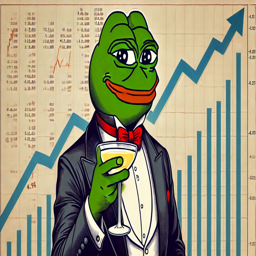

In [70]:
first_img

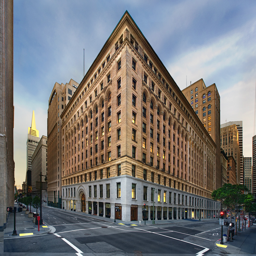

In [71]:
second_img

Convolutions have some interesting usages in image processing. For example, you can extract edges from an image by applying a convolution with a kernel that detects edges. Or you can convolve a specific kernel with your image to make it grayscale or blurred! Look at the definitions below:

__Edge Detection Kernel__:

_Sobel_ is one of the most famous edge detection kernels. It has two kernels, one for detecting vertical edges and the other for horizontal edges. You can see the kernels below:
$$
\text{Sobel}_x = \begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

$$
\text{Sobel}_y = \begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$$


__Grayscale Kernel__:

You can simply convolve the image with the following kernel to make it grayscale:

$$
\text{Grayscale\_across\_R} = \begin{bmatrix}
0 & 0 & 0 \\
0 & 0.3 & 0 \\
0 & 0 & 0
\end{bmatrix}
$$

$$
\text{Grayscale\_across\_G} = \begin{bmatrix}
0 & 0 & 0 \\
0 & 0.6 & 0 \\
0 & 0 & 0
\end{bmatrix}
$$

$$
\text{Grayscale\_across\_B} = \begin{bmatrix}
0 & 0 & 0 \\
0 & 0.1 & 0 \\
0 & 0 & 0
\end{bmatrix}
$$

(Convolve each kernel with its corresponding channel)

__Blurring Kernel__:

One of the famous kernels to blur an image is _Gaussian Blur_. You can see the kernel below:

$$
\text{Gaussian\_Blur} = \frac{1}{16} \times \begin{bmatrix}
1 & 2 & 1 \\
2 & 4 & 2 \\
1 & 2 & 1
\end{bmatrix}
$$


In [72]:
img_size = 256
x = np.zeros((2, 3, img_size, img_size))
x[0] = np.array(first_img).transpose(2, 0, 1)
x[1] = np.array(second_img).transpose(2, 0, 1)
# a convolution weight, holding 4 filters 3x3
w = np.zeros((4, 3, 3, 3))
w[0, 0] = np.array([[0, 0, 0], [0, 0.3, 0], [0, 0, 0]])  # R channel
w[0, 1] = np.array([[0, 0, 0], [0, 0.6, 0], [0, 0, 0]])  # G channel
w[0, 2] = np.array([[0, 0, 0], [0, 0.1, 0], [0, 0, 0]])  # B channel
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
w[1, :, :, :] = np.stack([sobel_x] * 3)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
w[2, :, :, :] = np.stack([sobel_y] * 3)
gauss_kernel = (1 / 16) * np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]])
w[3, 0] = gauss_kernel
w[3, 1] = gauss_kernel
w[3, 2] = gauss_kernel

b = np.array([0, 128, 128, 0])
conv = MyConv(stride=1, padding=1)
out = conv.forward(x, w, b) 

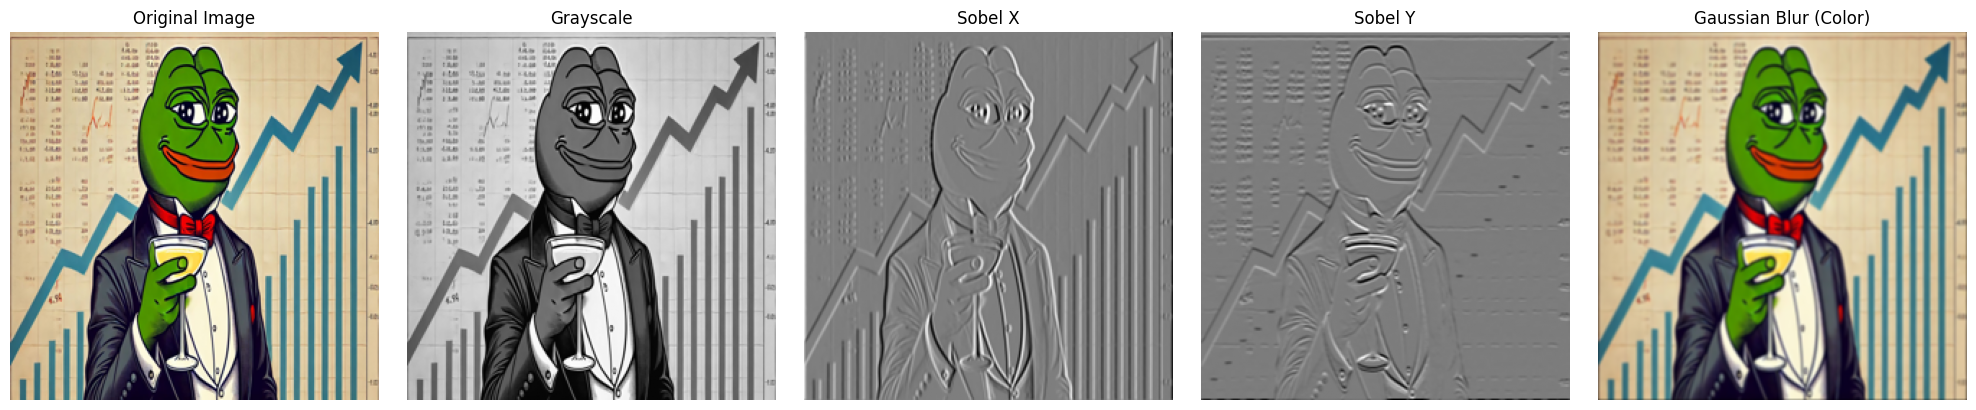

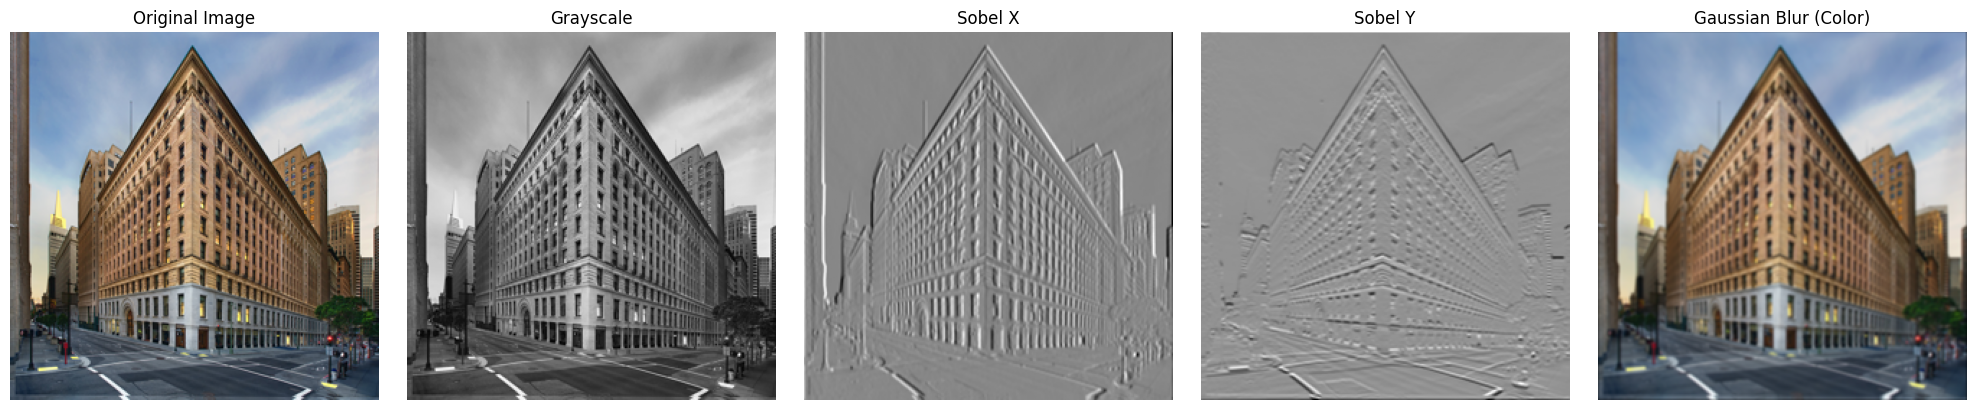

In [73]:
def custom_color_gaussian_blur(img, kernel, stride=1, padding=1):
    C, H, W = img.shape
    HH, WW = kernel.shape
    H_out = int((H + 2 * padding - HH) / stride + 1)
    W_out = int((W + 2 * padding - WW) / stride + 1)
    img_padded = np.pad(img, ((0, 0), (padding, padding), (padding, padding)), mode='constant')
    blurred = np.zeros((H_out, W_out, 3))
    for c in range(3):
        for i in range(H_out):
            for j in range(W_out):
                h_fom = i * stride
                h_to = h_fom + HH
                w_from = j * stride
                w_to = w_from + WW
                window = img_padded[c, h_fom:h_to, w_from:w_to]
                blurred[i, j, c] = np.sum(window * kernel)
    return blurred


for n in range(2):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    img = x[n].transpose(1, 2, 0) / 255.0
    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(out[n, 0], cmap='gray')
    axes[1].set_title("Grayscale")
    axes[1].axis('off')

    axes[2].imshow(out[n, 1], cmap='gray')
    axes[2].set_title("Sobel X")
    axes[2].axis('off')

    # Sobel Y
    axes[3].imshow(out[n, 2], cmap='gray')
    axes[3].set_title("Sobel Y")
    axes[3].axis('off')

    blurred_rgb = custom_color_gaussian_blur(x[n], gauss_kernel, stride=1, padding=1)
    blurred_rgb = np.clip(blurred_rgb / 255.0, 0, 1)
    axes[4].imshow(blurred_rgb)
    axes[4].set_title("Gaussian Blur (Color)")
    axes[4].axis('off')

    plt.tight_layout()
    plt.show()